In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb

# 1. Load and strictly clean data
gold = pd.read_csv('Gold Price.csv').sort_values('Date')
gold['Date'] = pd.to_datetime(gold['Date'])
if gold['Price'].dtype == 'O': gold['Price'] = gold['Price'].str.replace(',', '').astype(float)

usd = pd.read_csv('USD_INR Historical Data (1).csv').sort_values('Date')
usd['Date'] = pd.to_datetime(usd['Date'], dayfirst=True)
if usd['Price'].dtype == 'O': usd['Price'] = usd['Price'].str.replace(',', '').astype(float)

# Merge
df = pd.merge(gold[['Date', 'Price']], usd[['Date', 'Price']], on='Date', how='inner', suffixes=('_Gold', '_USD'))
df = df.sort_values('Date')

# --- THE KEY FIX ---
# Instead of Returns (%), let's use Price Difference (INR Change)
# This is even more stable for XGBoost.
df['Price_Diff'] = df['Price_Gold'].diff()
df['Gold_Lag'] = df['Price_Gold'].shift(1)
df['USD_Lag'] = df['Price_USD'].shift(1)
df = df.dropna()

# Features and Target
# We are training the model to predict the CHANGE, not the total price.
features = ['Gold_Lag', 'USD_Lag']
X = df[features]
y = df['Price_Diff'] # <--- MODEL LEARNS THE "JUMP", NOT THE "LEVEL"

# Train
xgb_final = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5)
xgb_final.fit(X, y)

# --- THE PREDICTION LOGIC ---
manual_date = "2026-02-01" # Edit this
target_dt = pd.to_datetime(manual_date)

# Get the last known price (should be ~117,370)
last_known_price = df['Price_Gold'].iloc[-1]
last_known_date = df['Date'].iloc[-1]
last_known_usd = df['Price_USD'].iloc[-1]

print(f"Starting Prediction from: {last_known_date.date()}")
print(f"Starting Price: {last_known_price} INR")

days_ahead = (target_dt - last_known_date).days

current_price = last_known_price
for i in range(days_ahead):
    # Predict the INR change for today
    input_data = pd.DataFrame([[current_price, last_known_usd]], columns=features)
    predicted_change = xgb_final.predict(input_data)[0]

    # ADD the change to the current price
    current_price = current_price + predicted_change

print(f"--- RESULT ---")
print(f"Predicted Price for {target_dt.date()}: {current_price:.2f} INR")

Starting Prediction from: 2025-10-03
Starting Price: 117370 INR
--- RESULT ---
Predicted Price for 2026-02-01: 190026.33 INR


--- Corrected Model Accuracy Report ---
New Accuracy: 99.20%
Mean Error: 627.76 INR
R2 Score: 0.9969


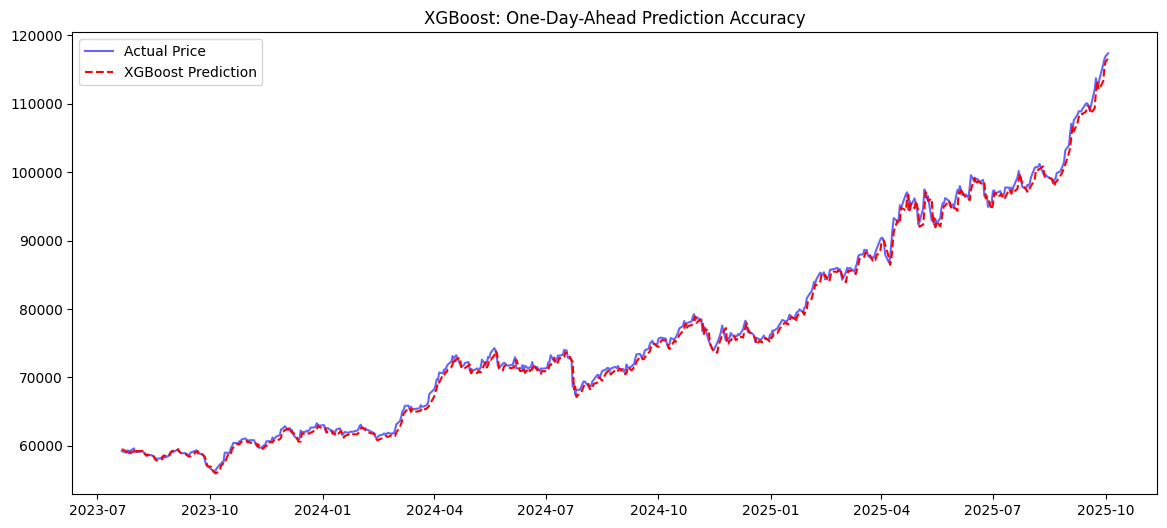

In [ ]:
# 1. One-Day-Ahead Prediction (The standard for financial accuracy)
# We use the actual 'Lag' values from the test set
X_test_real = test_df[features]
test_preds_diff = xgb_eval.predict(X_test_real)

# 2. Reconstruct the price: Yesterday's Real Price + AI's predicted change
corrected_preds = test_df['Gold_Lag'].values + test_preds_diff

# 3. Recalculate Metrics
actuals = test_df['Price_Gold'].values
mape = np.mean(np.abs((actuals - corrected_preds) / actuals)) * 100
accuracy = 100 - mape
mae = mean_absolute_error(actuals, corrected_preds)
r2 = r2_score(actuals, corrected_preds)

print(f"--- Corrected Model Accuracy Report ---")
print(f"New Accuracy: {accuracy:.2f}%")
print(f"Mean Error: {mae:.2f} INR")
print(f"R2 Score: {r2:.4f}")

# 4. Comparison Plot
plt.figure(figsize=(14, 6))
plt.plot(test_df['Date'], actuals, label='Actual Price', color='blue', alpha=0.6)
plt.plot(test_df['Date'], corrected_preds, label='XGBoost Prediction', color='red', linestyle='--')
plt.title("XGBoost: One-Day-Ahead Prediction Accuracy")
plt.legend()
plt.show()